# Análisis de resultados de experimentos computacionales

In [1]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.dpi'] = 300

---

### Lectura, Extracción y Almacenamiento de resultados

In [2]:
RESULTS_DIR = "../RESULTS"
ALGORITMOS = ["CLASSIC", "QLEARNING"]

datos_experimentos = []
print("Iniciando la lectura masiva y análisis de convergencia...")

for algo in ALGORITMOS:
    path_busqueda = os.path.join(RESULTS_DIR, algo, "metrics", "*.csv")
    archivos_csv = glob.glob(path_busqueda)
    
    for ruta_archivo in archivos_csv:
        nombre_archivo = os.path.basename(ruta_archivo)
        partes = nombre_archivo.replace(".csv", "").split("_")
        
        if len(partes) >= 4:
            instancia = partes[1]
            run_id = partes[3].replace("run", "")
            
            try:
                df_run = pd.read_csv(ruta_archivo)
                
                if not df_run.empty:
                    ultima_fila = df_run.iloc[-1]
                    final_veh = ultima_fila['best_veh']
                    final_dist = ultima_fila['best_dist']
                    
                    idx_convergencia = df_run[(df_run['best_veh'] == final_veh) & 
                                              (df_run['best_dist'] == final_dist)].index[0]
                    
                    iter_optimo = df_run.loc[idx_convergencia, 'iter']
                    
                    datos_experimentos.append({
                        "Algoritmo": algo,
                        "Instancia": instancia.lower(),
                        "Run": int(run_id),
                        "Vehiculos": final_veh,      
                        "Distancia": final_dist,     
                        "Iter_Convergencia": iter_optimo
                    })
            except Exception as e:
                print(f"[ERROR] En {nombre_archivo}: {e}")

df_master = pd.DataFrame(datos_experimentos)
print(f"Extracción completada: {len(df_master)} corridas procesadas.")

df_master.head()

Iniciando la lectura masiva y análisis de convergencia...
Extracción completada: 1120 corridas procesadas.


,Algoritmo,Instancia,Run,Vehiculos,Distancia,Iter_Convergencia
0,CLASSIC,c101,1,10.0,828.937,6
1,CLASSIC,c101,10,10.0,828.937,191
2,CLASSIC,c101,2,10.0,828.937,69
3,CLASSIC,c101,3,10.0,828.937,223
4,CLASSIC,c101,4,10.0,828.937,111


In [3]:
ruta_tiempos = os.path.join(RESULTS_DIR, "tiempos_ejecucion_limpios.csv")

try:
    df_tiempos = pd.read_csv(ruta_tiempos)
    df_tiempos['Instancia'] = df_tiempos['Instancia'].astype(str).str.lower().str.strip()
    
    df_master = pd.merge(df_master, df_tiempos, on=['Instancia', 'Algoritmo', 'Run'], how='inner')
    
    print("=== INTEGRACIÓN DE TIEMPOS COMPLETADA ===")
    print(f"Total de filas consolidadas: {len(df_master)}")
    
except FileNotFoundError:
    print(f"[ERROR] No se encontró el archivo en: {ruta_tiempos}")

df_master.head()

=== INTEGRACIÓN DE TIEMPOS COMPLETADA ===
Total de filas consolidadas: 1120


,Algoritmo,Instancia,Run,Vehiculos,Distancia,Iter_Convergencia,Tiempo_s
0,CLASSIC,c101,1,10.0,828.937,6,4.6382
1,CLASSIC,c101,10,10.0,828.937,191,4.5266
2,CLASSIC,c101,2,10.0,828.937,69,4.7400
3,CLASSIC,c101,3,10.0,828.937,223,4.6355
4,CLASSIC,c101,4,10.0,828.937,111,4.7413


---

### GAP de resultados vs BKS del SINTEF

In [10]:
# BKS del SINTEF
ruta_sintef = "sintef.csv" 
df_bks = pd.read_csv(ruta_sintef, sep=';')
df_bks['Instancia'] = df_bks['Instancia'].astype(str).str.lower().str.strip()
df_bks.rename(columns={'Vehículos': 'BKS_Vehiculos', 'Distancia': 'BKS_Distancia'}, inplace=True)

# Mejores resultados por instancia (ALNS y ALNS-Q)
df_ordenado = df_master.sort_values(by=['Vehiculos', 'Distancia'], ascending=[True, True])
df_mejores = df_ordenado.groupby(['Instancia', 'Algoritmo']).first().reset_index()

# Promedios por instancia (ALNS y ALNS-Q)
df_promedios = df_master.groupby(['Instancia', 'Algoritmo']).agg(
    Vehiculos_Promedio=('Vehiculos', 'mean'),        # F_1 Promedio
    Distancia_Promedio=('Distancia', 'mean'),        # F_2 Promedio
    Iter_Conv_Promedio=('Iter_Convergencia', 'mean'),# Convergencia Promedio
    Tiempo_Mejor=('Tiempo_s', 'min'),                # CPU Mejor
    Tiempo_Promedio=('Tiempo_s', 'mean')             # CPU Promedio
).reset_index()

# Agrupar y cruzar
df_agrupado = pd.merge(df_mejores, df_promedios, on=['Instancia', 'Algoritmo'])
df_analisis = pd.merge(df_agrupado, df_bks, on='Instancia', how='inner')

# GAPS de resultados vs SINTEF
df_analisis['Delta_Vehiculos'] = df_analisis['Vehiculos'] - df_analisis['BKS_Vehiculos']
df_analisis['GAP_Dist_Mejor (%)'] = ((df_analisis['Distancia'] - df_analisis['BKS_Distancia']) / df_analisis['BKS_Distancia']) * 100
df_analisis['GAP_Dist_Prom (%)'] = ((df_analisis['Distancia_Promedio'] - df_analisis['BKS_Distancia']) / df_analisis['BKS_Distancia']) * 100

# Pivot para ALNS vs ALNS-Q
columnas_clave = [
    'Instancia', 'Algoritmo', 
    'Vehiculos', 'Distancia',                      # F_1 y F_2 Mejores
    'Vehiculos_Promedio', 'Distancia_Promedio',    # F_1 y F_2 Promedios
    'Delta_Vehiculos',                             # Diferencia vs BKS
    'GAP_Dist_Mejor (%)', 'GAP_Dist_Prom (%)',     # GAPs
    'Iter_Convergencia', 'Iter_Conv_Promedio',     # Convergencias
    'Tiempo_Mejor', 'Tiempo_Promedio'              # Tiempos CPU
]
df_pivot = df_analisis[columnas_clave].pivot(index='Instancia', columns='Algoritmo')
df_pivot.columns = [f"{algo}_{metrica}" for metrica, algo in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# TABLA FINAL
tabla_final = pd.merge(df_bks, df_pivot, on='Instancia', how='inner')

print("=======================================================")
print("      RESUMEN DE RENDIMIENTO")
print("=======================================================")
for algo in ["CLASSIC", "QLEARNING"]:
    suma_delta = tabla_final[f'{algo}_Delta_Vehiculos'].sum()
    instancias_exitosas = tabla_final[tabla_final[f'{algo}_Delta_Vehiculos'] == 0]
    gap_mejor_filtrado = instancias_exitosas[f'{algo}_GAP_Dist_Mejor (%)'].mean()
    gap_prom_filtrado = instancias_exitosas[f'{algo}_GAP_Dist_Prom (%)'].mean()
    tiempo_cpu_promedio = tabla_final[f'{algo}_Tiempo_Promedio'].mean()
    
    print(f"\n--- {algo} ---")
    print(f"  Suma Delta Vehículos             : +{suma_delta}")
    print(f"  GAP Dist. Mejor (Solo Delta=0)   : {gap_mejor_filtrado:.3f}% (Muestra: {len(instancias_exitosas)} inst.)")
    print(f"  GAP Dist. Prom. (Solo Delta=0)   : {gap_prom_filtrado:.3f}%")
    print(f"  Tiempo CPU Promedio Global       : {tiempo_cpu_promedio:.3f}s")

tabla_final.to_csv('Tabla_Resultados_ALNS_ALNSQ.csv', index=False)
print("\n=======================================================")
print(f"[INFO] Dataset final ({len(tabla_final.columns)} columnas) guardado en 'Tabla_Resultados_ALNS_ALNSQ.csv'")

tabla_final.head()

      RESUMEN DE RENDIMIENTO

--- CLASSIC ---
  Suma Delta Vehículos             : +16.0
  GAP Dist. Mejor (Solo Delta=0)   : 0.293% (Muestra: 40 inst.)
  GAP Dist. Prom. (Solo Delta=0)   : 0.590%
  Tiempo CPU Promedio Global       : 5.579s

--- QLEARNING ---
  Suma Delta Vehículos             : +14.0
  GAP Dist. Mejor (Solo Delta=0)   : 0.361% (Muestra: 42 inst.)
  GAP Dist. Prom. (Solo Delta=0)   : 0.526%
  Tiempo CPU Promedio Global       : 5.206s

[INFO] Dataset final (25 columnas) guardado en 'Tabla_Resultados_ALNS_ALNSQ.csv'


,Instancia,BKS_Vehiculos,BKS_Distancia,CLASSIC_Vehiculos,QLEARNING_Vehiculos,CLASSIC_Distancia,QLEARNING_Distancia,CLASSIC_Vehiculos_Promedio,QLEARNING_Vehiculos_Promedio,CLASSIC_Distancia_Promedio,...,CLASSIC_GAP_Dist_Prom (%),QLEARNING_GAP_Dist_Prom (%),CLASSIC_Iter_Convergencia,QLEARNING_Iter_Convergencia,CLASSIC_Iter_Conv_Promedio,QLEARNING_Iter_Conv_Promedio,CLASSIC_Tiempo_Mejor,QLEARNING_Tiempo_Mejor,CLASSIC_Tiempo_Promedio,QLEARNING_Tiempo_Promedio
0,c101,10,828.94,10.0,10.0,828.937,828.937,10.0,10.0,828.937,...,-0.000362,-0.000362,6,24,84.8,58.2,4.3867,4.7059,4.60479,5.27034
1,c102,10,828.94,10.0,10.0,828.937,828.937,10.0,10.0,828.937,...,-0.000362,-0.000362,60,65,147.2,121.7,5.1335,4.2040,5.29811,4.94466
2,c103,10,828.06,10.0,10.0,828.065,828.065,10.0,10.0,828.065,...,0.000604,0.000604,679,1085,828.8,609.1,5.6701,4.7930,5.82982,5.06725
3,c104,10,824.78,10.0,10.0,824.777,824.777,10.0,10.0,824.777,...,-0.000364,-0.000364,6415,3311,5769.5,3891.8,5.9624,5.7741,6.12322,6.43294
4,c105,10,828.94,10.0,10.0,828.937,828.937,10.0,10.0,828.937,...,-0.000362,-0.000362,266,24,116.6,39.7,4.7569,4.8579,4.86481,5.46039


---

### Convergencia y Tiempo de ejecución

C:\Users\josew\AppData\Local\Temp\ipykernel_19776\2130002885.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_iter, x='Algoritmo', y='Iteraciones',
C:\Users\josew\AppData\Local\Temp\ipykernel_19776\2130002885.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tiempo, x='Algoritmo', y='Tiempo (s)',


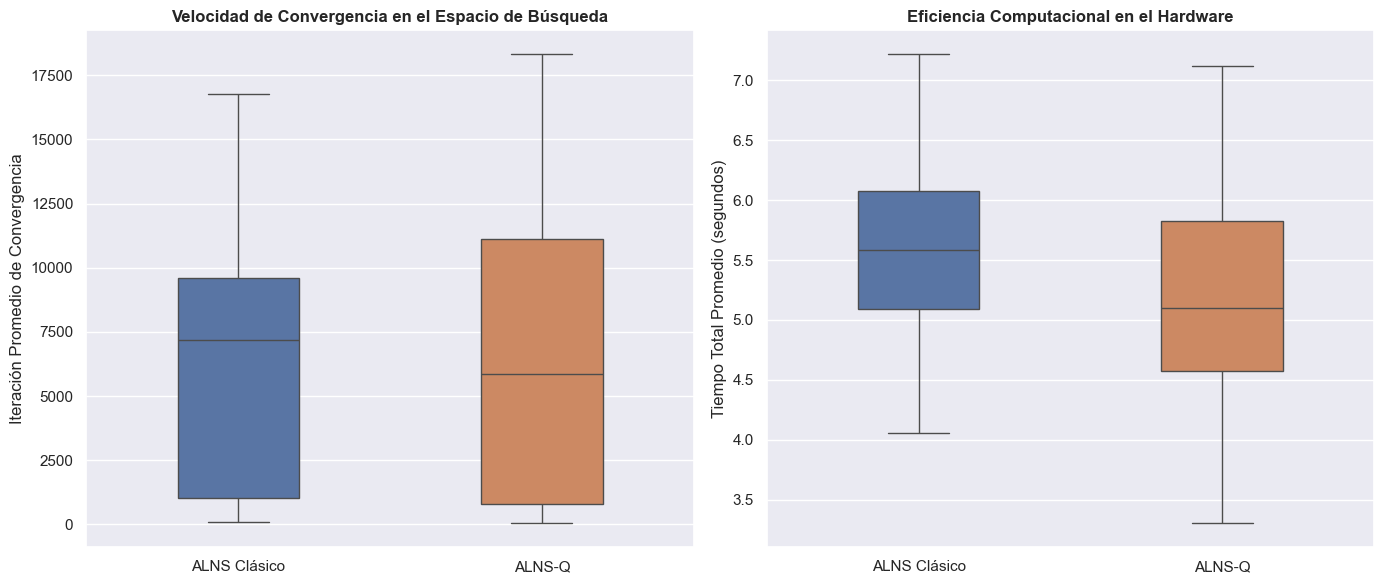

In [12]:
df_iter = pd.DataFrame({
    'Algoritmo': ['ALNS Clásico'] * len(tabla_final) + ['ALNS-Q'] * len(tabla_final),
    'Iteraciones': list(tabla_final['CLASSIC_Iter_Conv_Promedio']) + list(tabla_final['QLEARNING_Iter_Conv_Promedio'])
})

df_tiempo = pd.DataFrame({
    'Algoritmo': ['ALNS Clásico'] * len(tabla_final) + ['ALNS-Q'] * len(tabla_final),
    'Tiempo (s)': list(tabla_final['CLASSIC_Tiempo_Promedio']) + list(tabla_final['QLEARNING_Tiempo_Promedio'])
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_iter, x='Algoritmo', y='Iteraciones', 
            palette=['#4C72B0', '#DD8452'], width=0.4, ax=axes[0])
axes[0].set_title('Velocidad de Convergencia en el Espacio de Búsqueda', fontweight='bold')
axes[0].set_ylabel('Iteración Promedio de Convergencia')
axes[0].set_xlabel('')

sns.boxplot(data=df_tiempo, x='Algoritmo', y='Tiempo (s)', 
            palette=['#4C72B0', '#DD8452'], width=0.4, ax=axes[1])
axes[1].set_title('Eficiencia Computacional en el Hardware', fontweight='bold')
axes[1].set_ylabel('Tiempo Total Promedio (segundos)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('Boxplots_Eficiencia_Comparativa.png', dpi=300)
plt.show()

### Hay relación entre el número de iteraciones vs tiempo CPU?

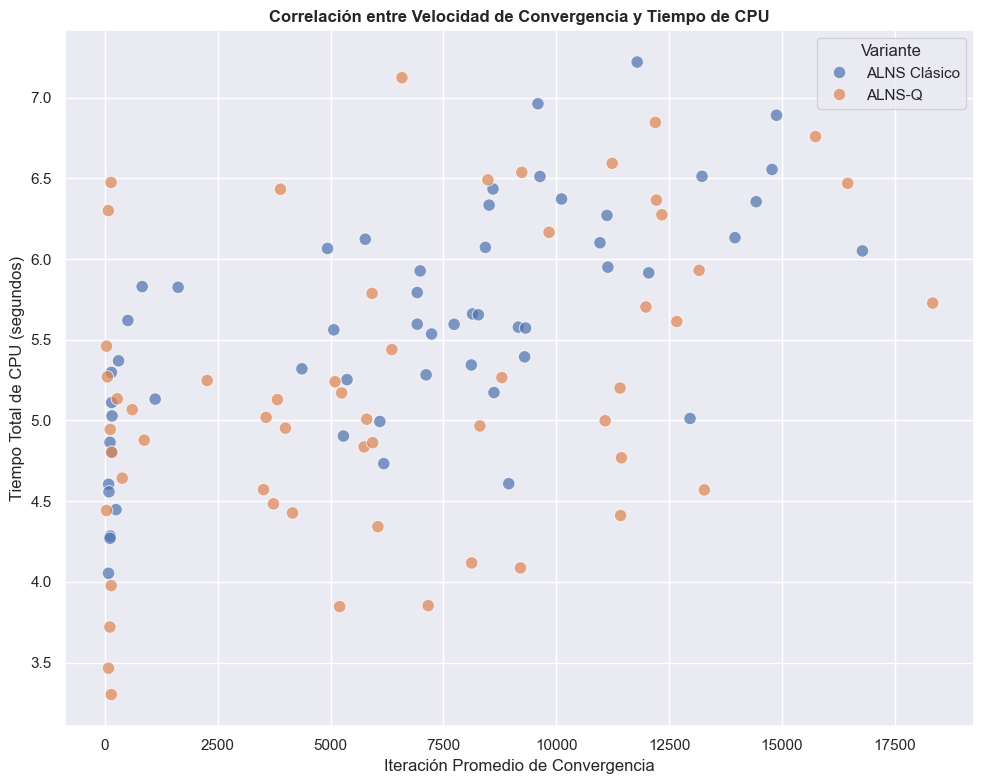

In [11]:
plt.figure(figsize=(10, 8))

df_classic = tabla_final[['Instancia', 'CLASSIC_Iter_Conv_Promedio', 'CLASSIC_Tiempo_Promedio']].copy()
df_classic['Algoritmo'] = 'ALNS Clásico'
df_classic.rename(columns={'CLASSIC_Iter_Conv_Promedio': 'Iter_Convergencia', 'CLASSIC_Tiempo_Promedio': 'Tiempo_CPU'}, inplace=True)

df_qlearning = tabla_final[['Instancia', 'QLEARNING_Iter_Conv_Promedio', 'QLEARNING_Tiempo_Promedio']].copy()
df_qlearning['Algoritmo'] = 'ALNS-Q'
df_qlearning.rename(columns={'QLEARNING_Iter_Conv_Promedio': 'Iter_Convergencia', 'QLEARNING_Tiempo_Promedio': 'Tiempo_CPU'}, inplace=True)

df_scatter = pd.concat([df_classic, df_qlearning])

sns.scatterplot(data=df_scatter, x='Iter_Convergencia', y='Tiempo_CPU', hue='Algoritmo', 
                palette=['#4C72B0', '#DD8452'], alpha=0.7, s=80)

plt.title('Correlación entre Velocidad de Convergencia y Tiempo de CPU', fontweight='bold')
plt.xlabel('Iteración Promedio de Convergencia')
plt.ylabel('Tiempo Total de CPU (segundos)')
plt.legend(title='Variante')
plt.tight_layout()
plt.savefig('Scatter_Eficiencia_Dual.png')
plt.show()

No hay correlación.